In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
print(np.__version__)
print(pd.__version__)

1.26.4
2.3.2


In [8]:
ap_mean_by_xy = pd.read_csv("./ap_mean_by_xy.csv")
ap_median_by_xy = pd.read_csv("./ap_median_by_xy.csv")
ap_mean_by_xy_imputed = pd.read_csv('./ap_mean_by_xy_imputed_IDW.csv')
ap_median_by_xy_imputed = pd.read_csv('./ap_median_by_xy_imputed_IDW.csv')

In [22]:
def plot_RF(floor_df, label):
    fig, ax = plt.subplots()
    ax.scatter(floor_df['X'], floor_df['Y'])
    ax.set_xlabel('X(m)')
    ax.set_ylabel('Y(m)')
    ax.set_title(label)
    plt.show()

In [23]:
# Feature Columns
def get_ap_columns(dataset):
    return [col for col in dataset.columns if col.startswith('AP')]

In [27]:
def plot_indoor_localization_results(true_locations, predicted_locations, title):
    # Plotting
    plt.figure(figsize=(8, 6))

    # Scatter plots for the points
    plt.scatter(true_locations[:, 0], true_locations[:, 1], c='yellow', marker='x', s=100, label="True locations")
    plt.scatter(predicted_locations[:, 0], predicted_locations[:, 1], c='r', alpha=0.5, label="KNN (model trained data)")


    # Draw lines connecting the true points with synthetic predictions
    for i in range(len(true_locations)):
        plt.plot([true_locations[i, 0], predicted_locations[i, 0]],
                [true_locations[i, 1], predicted_locations[i, 1]],
                c='red', linestyle=':', linewidth=1)  # Lines between true and synthetic

    # Labels and title
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()

    # Show the plot
    plt.show()

In [9]:
def subsample_every_n(df, N, origin=(None,None), tol=1e-8):
    """
    Split df into two parts:
      • df_kept: rows where (X−x0) and (Y−y0) are multiples of N
      • df_rest: all the other rows

    Parameters
    ----------
    df : DataFrame with columns 'X','Y'
    N  : float           the grid spacing you want (e.g. 5.0)
    origin : (x0,y0)     the “zero” of your grid; if None, uses (min X, min Y)
    tol : float          tolerance for floating-point modulo

    Returns
    -------
    df_kept, df_rest : DataFrames
    """
    df2 = df.copy()

    # 1) determine grid origin
    x0 = origin[0] if origin[0] is not None else df2['X'].min()
    y0 = origin[1] if origin[1] is not None else df2['Y'].min()

    # 2) compute offsets
    dx = df2['X'] - x0
    dy = df2['Y'] - y0

    # 3) boolean mask for “on-grid” points
    on_grid = (
        np.isclose(dx.mod(N), 0.0, atol=tol) &
        np.isclose(dy.mod(N), 0.0, atol=tol)
    )

    # 4) split
    df_kept = df2.loc[on_grid].reset_index(drop=True)
    df_rest = df2.loc[~on_grid].reset_index(drop=True)

    return df_kept, df_rest

In [10]:
# Define a function to compute the Euclidean distance error.
def compute_localization_errors(true_locations, predicted_locations):
    errors = np.sqrt(np.sum((true_locations - predicted_locations)**2, axis=1))
    return errors

In [11]:
def fraction(actual, orig):
    return actual.shape[0] / orig.shape[0] * 100

### KNN Imputer

In [40]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5, weights='uniform')

columns_to_exclude = ['X', 'Y']
data_to_impute = ap_mean_by_xy.drop(columns=columns_to_exclude)
imputed_values = imputer.fit_transform(data_to_impute)
df_mean_imputed_knn = ap_mean_by_xy.copy()

df_mean_imputed_knn[data_to_impute.columns] = imputed_values

print(f"\nTotal NaNs in original DataFrame: {ap_mean_by_xy.isna().sum().sum()}")
print(f"Total NaNs in new KNN imputed DataFrame: {df_mean_imputed_knn.isna().sum().sum()}")


Total NaNs in original DataFrame: 476
Total NaNs in new KNN imputed DataFrame: 0


In [41]:
imputer = KNNImputer(n_neighbors=5, weights='uniform')

columns_to_exclude = ['X', 'Y']
data_to_impute = ap_median_by_xy.drop(columns=columns_to_exclude)
imputed_values = imputer.fit_transform(data_to_impute)
df_median_imputed_knn = ap_median_by_xy.copy()

df_median_imputed_knn[data_to_impute.columns] = imputed_values

print(f"\nTotal NaNs in original DataFrame: {ap_median_by_xy.isna().sum().sum()}")
print(f"Total NaNs in new KNN imputed DataFrame: {df_median_imputed_knn.isna().sum().sum()}")


Total NaNs in original DataFrame: 476
Total NaNs in new KNN imputed DataFrame: 0


In [42]:
training_df_mean, test_df_mean = subsample_every_n(df_mean_imputed_knn, 2, (0,0))
training_df_median, test_df_median = subsample_every_n(df_median_imputed_knn, 2, (0,0))
training_df_mean_imputed, test_df_mean_imputed = subsample_every_n(ap_mean_by_xy_imputed, 2, (0,0))
training_df_median_imputed, test_df_median_imputed = subsample_every_n(ap_median_by_xy_imputed, 2, (0,0))

In [43]:
print(f"Fraction (original mean): {fraction(training_df_mean, ap_mean_by_xy)}")
print(f"Fraction (original median): {fraction(training_df_median, ap_median_by_xy)}")
print(f"Fraction (imputed mean): {fraction(training_df_mean_imputed, ap_mean_by_xy_imputed)}")
print(f"Fraction (imputed median: {fraction(training_df_median_imputed, ap_median_by_xy_imputed)}")

Fraction (original mean): 23.684210526315788
Fraction (original median): 23.684210526315788
Fraction (imputed mean): 23.684210526315788
Fraction (imputed median: 23.684210526315788


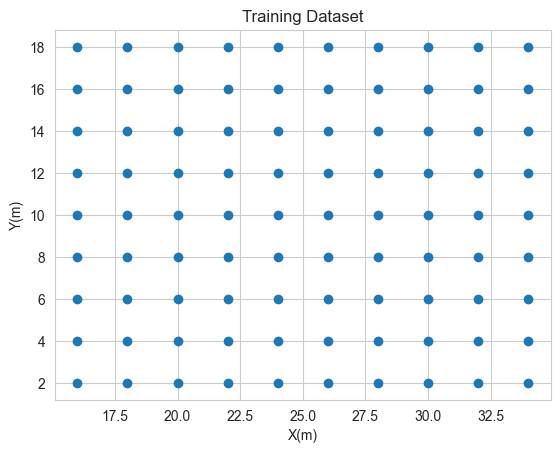

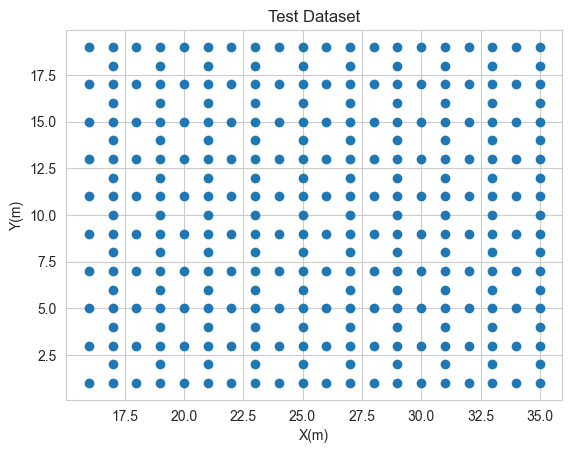

In [44]:
plot_RF(training_df_mean, "Training Dataset")
plot_RF(test_df_mean, "Test Dataset")

## KNN Model Evaluation

In [45]:
cond_cols = ['X','Y']

In [71]:
def knn_evaluation(X_train, X_test, y_train, y_test, plot_label="Localization errors"):
    knn_scaler=StandardScaler()
    X_ap_train_scaled = knn_scaler.fit_transform(X_train)

    # --- Custom Weight Function (1 / distance^2) ---
    def inverse_squared_weight(distances):
        # Avoid division by zero for exact matches
        # (replace 0 with a tiny number)
        distances = np.maximum(distances, 1e-10)
        return 1.0 / (distances ** 2)

    # KNN multi-output
    knn = KNeighborsRegressor(
        weights=inverse_squared_weight,
        metric='manhattan')

    param_grid = {'n_neighbors': range(3, 10)}
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_search.fit(X_ap_train_scaled, y_train)
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best score: {grid_search.best_score_}")

    knn_best = grid_search.best_estimator_

    pred_locations_test = knn_best.predict(knn_scaler.transform(X_test))

    print(f"Localization Error: {np.mean(compute_localization_errors(y_test, pred_locations_test))}")

    plot_indoor_localization_results(y_test, pred_locations_test, plot_label)

In [72]:
def evaluate_knn(train_dataset, test_dataset, plot_label="Localization errors"):
    X_ap_train = train_dataset[get_ap_columns(train_dataset)].values
    y_xy_train = train_dataset[cond_cols].values

    X_ap_test = test_dataset[get_ap_columns(test_dataset)].values
    y_xy_test = test_dataset[cond_cols].values

    knn_evaluation(X_ap_train, X_ap_test, y_xy_train, y_xy_test, plot_label=plot_label)

### 100% of the dataset

Best parameters: {'n_neighbors': 3}
Best score: -2.8519919547326724
Localization Error: 0.0


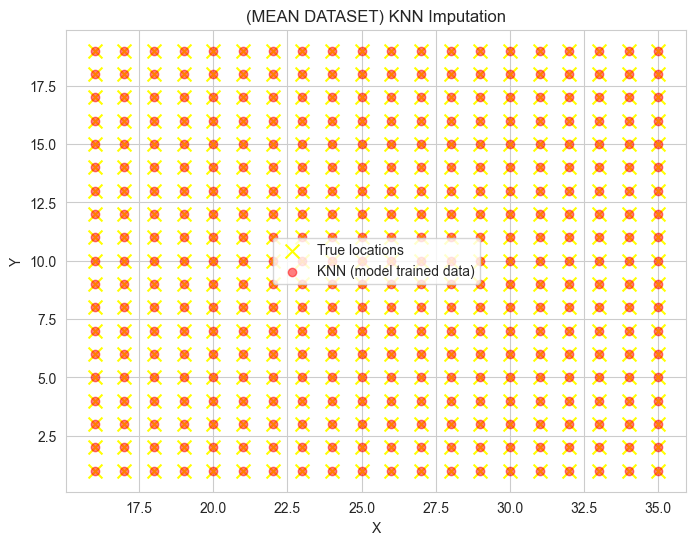

Best parameters: {'n_neighbors': 3}
Best score: -2.698432778814356
Localization Error: 0.0


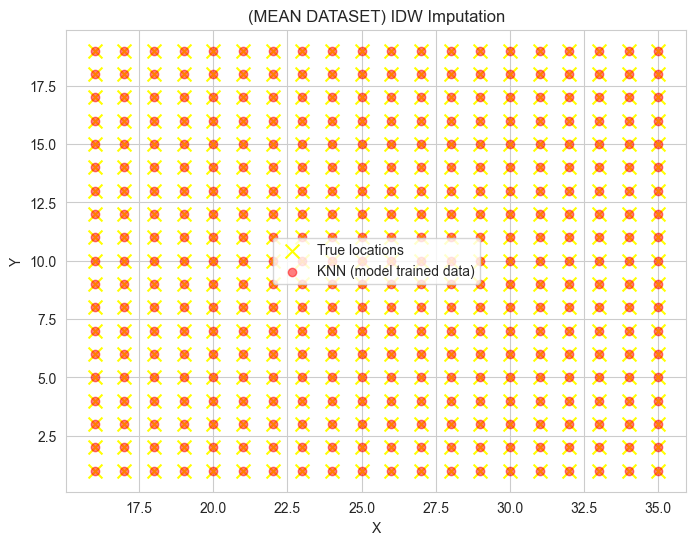

Best parameters: {'n_neighbors': 4}
Best score: -3.039677206967839
Localization Error: 0.0


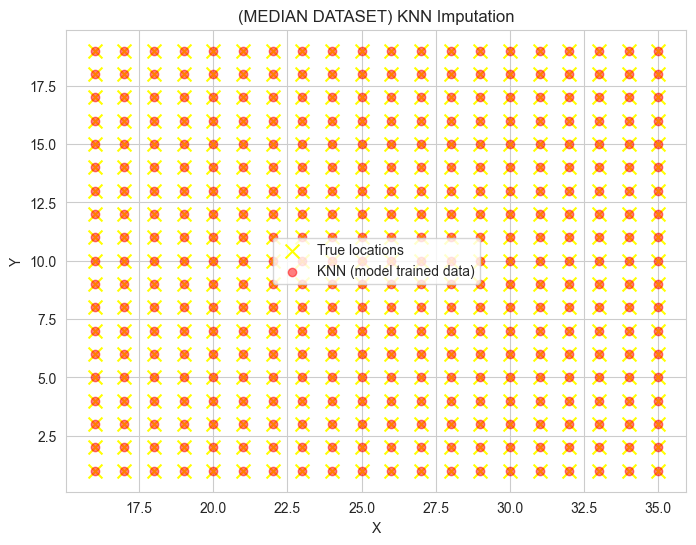

Best parameters: {'n_neighbors': 6}
Best score: -2.9155414898095655
Localization Error: 0.0


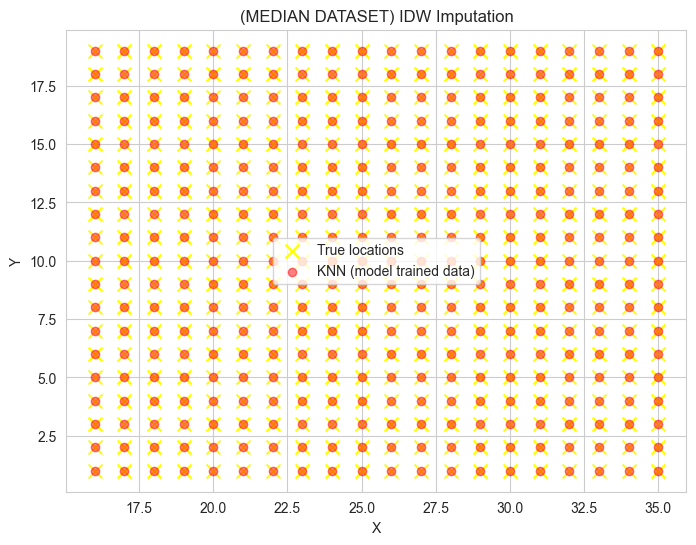

In [88]:
evaluate_knn(df_mean_imputed_knn, df_mean_imputed_knn, plot_label="(MEAN DATASET) KNN Imputation")
evaluate_knn(ap_mean_by_xy_imputed, ap_mean_by_xy_imputed, plot_label="(MEAN DATASET) IDW Imputation")
evaluate_knn(df_median_imputed_knn, df_median_imputed_knn, plot_label="(MEDIAN DATASET) KNN Imputation")
evaluate_knn(ap_median_by_xy_imputed, ap_median_by_xy_imputed, plot_label="(MEDIAN DATASET) IDW Imputation")

### Every 2nd

Best parameters: {'n_neighbors': 4}
Best score: -3.524978187777125
Localization Error: 2.6987342476631935


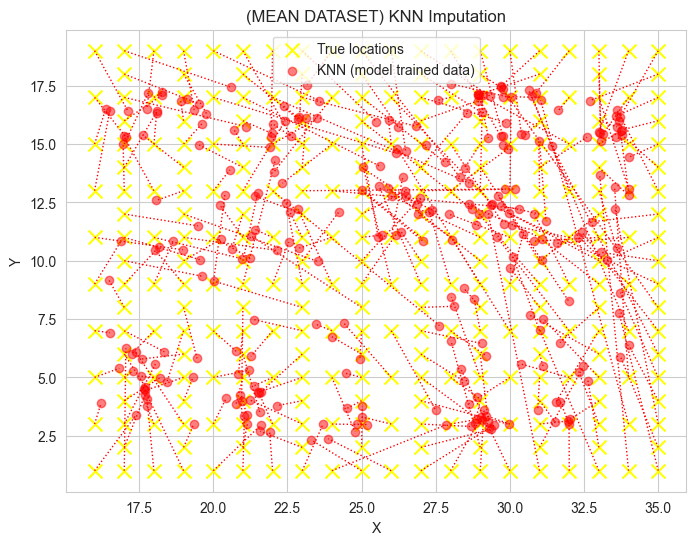

Best parameters: {'n_neighbors': 5}
Best score: -3.4191286874630875
Localization Error: 2.5349806017979146


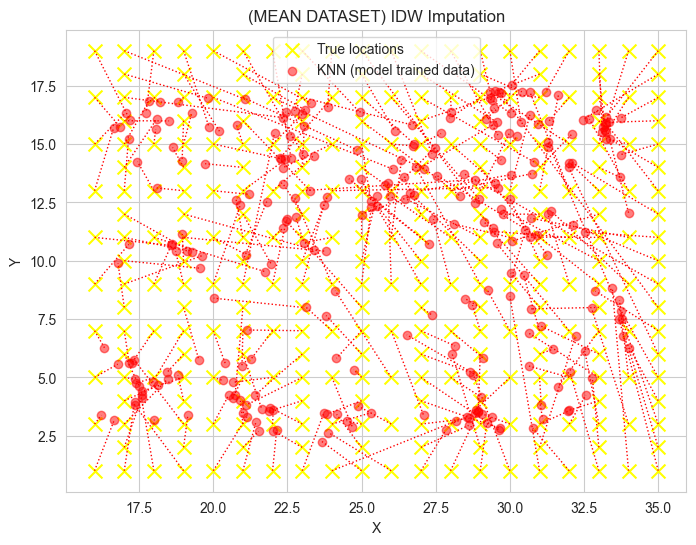

Best parameters: {'n_neighbors': 3}
Best score: -3.4286672601952857
Localization Error: 3.2412239122427695


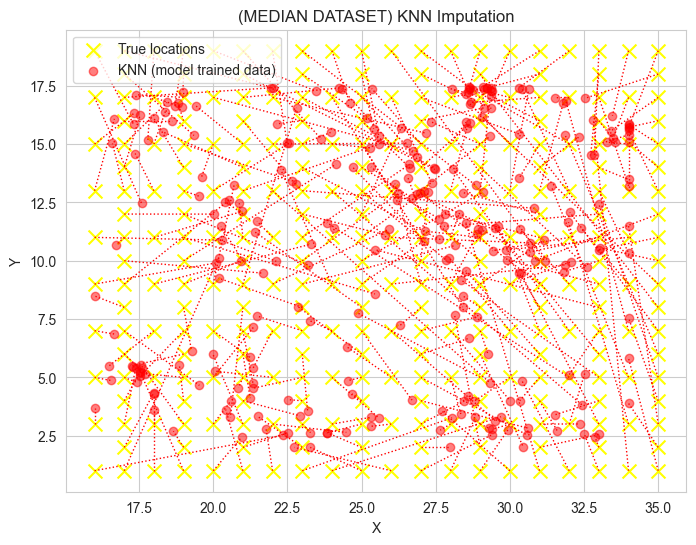

Best parameters: {'n_neighbors': 3}
Best score: -3.375515033316959
Localization Error: 3.013780750868845


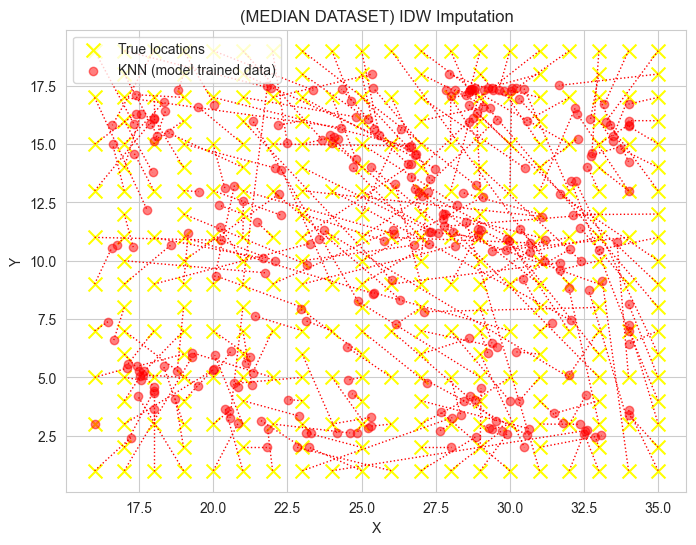

In [57]:
evaluate_knn(training_df_mean, test_df_mean, plot_label="(MEAN DATASET) KNN Imputation")
evaluate_knn(training_df_mean_imputed, test_df_mean_imputed, plot_label="(MEAN DATASET) IDW Imputation")
evaluate_knn(training_df_median, test_df_median, plot_label="(MEDIAN DATASET) KNN Imputation")
evaluate_knn(training_df_median_imputed, test_df_median_imputed, plot_label="(MEDIAN DATASET) IDW Imputation")

### Every 3rd

In [80]:
training_df_mean, test_df_mean = subsample_every_n(df_mean_imputed_knn, 3, (0,0))
training_df_median, test_df_median = subsample_every_n(df_median_imputed_knn, 3, (0,0))
training_df_mean_imputed, test_df_mean_imputed = subsample_every_n(ap_mean_by_xy_imputed, 3, (0,0))
training_df_median_imputed, test_df_median_imputed = subsample_every_n(ap_median_by_xy_imputed, 3, (0,0))

In [81]:
print(f"Fraction (original mean): {fraction(training_df_mean, ap_mean_by_xy)}")
print(f"Fraction (original median): {fraction(training_df_median, ap_median_by_xy)}")
print(f"Fraction (imputed mean): {fraction(training_df_mean_imputed, ap_mean_by_xy_imputed)}")
print(f"Fraction (imputed median: {fraction(training_df_median_imputed, ap_median_by_xy_imputed)}")

Fraction (original mean): 9.473684210526317
Fraction (original median): 9.473684210526317
Fraction (imputed mean): 9.473684210526317
Fraction (imputed median: 9.473684210526317


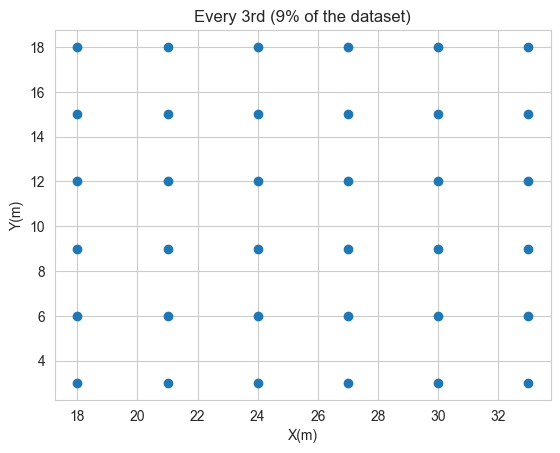

In [82]:
plot_RF(training_df_mean, "Every 3rd (9% of the dataset)")

Best parameters: {'n_neighbors': 3}
Best score: -3.15165602416164
Localization Error: 3.3421442080853825


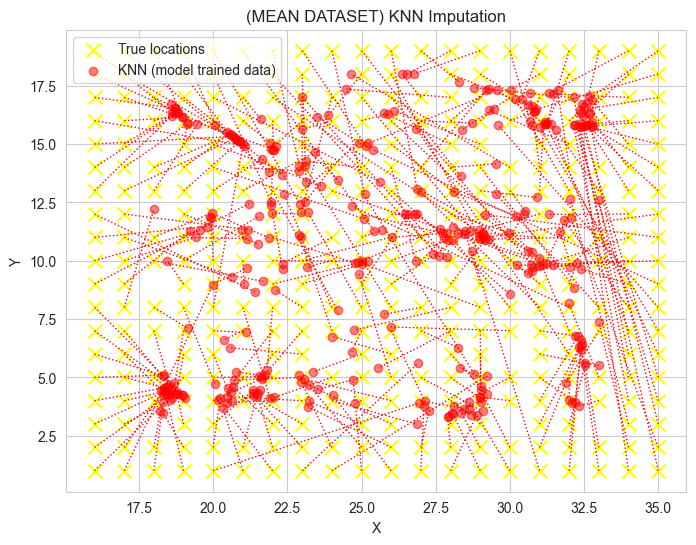

Best parameters: {'n_neighbors': 3}
Best score: -3.171459065299987
Localization Error: 3.269735612023027


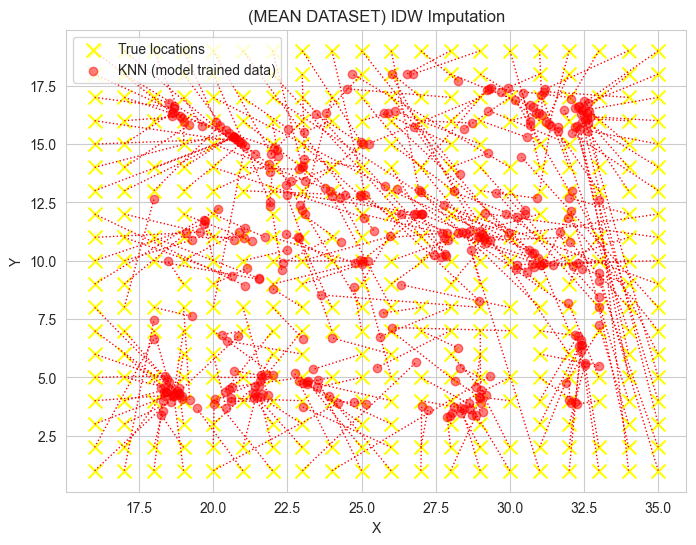

Best parameters: {'n_neighbors': 3}
Best score: -3.2585849470659953
Localization Error: 3.635713910271597


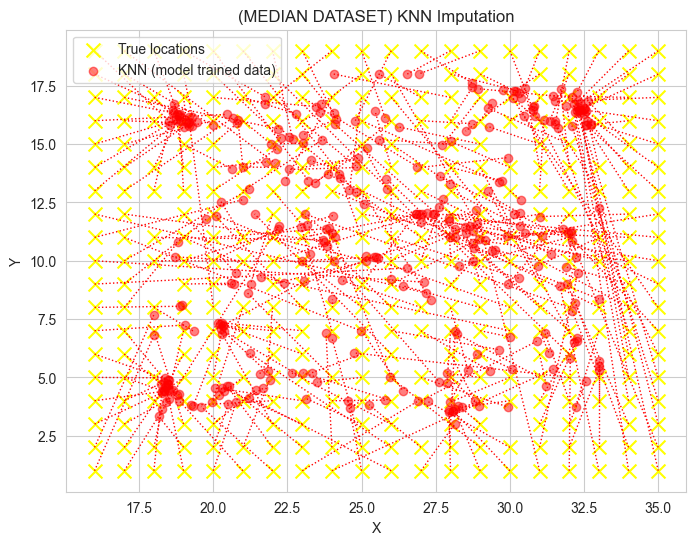

Best parameters: {'n_neighbors': 3}
Best score: -3.1363050822086698
Localization Error: 3.630416737370469


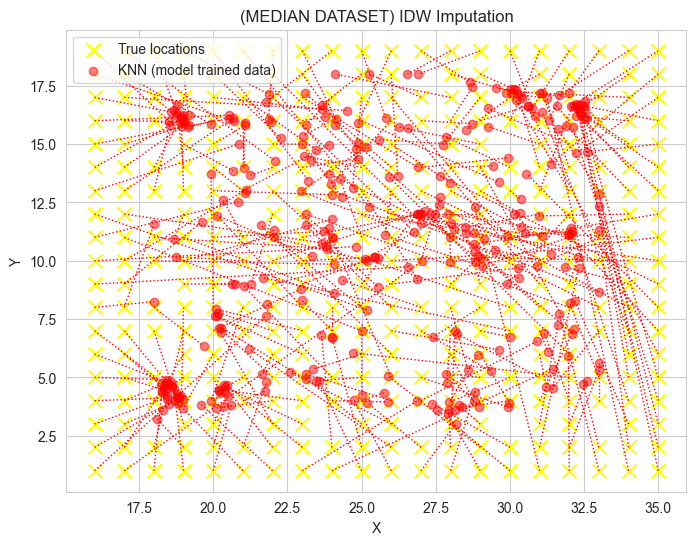

In [75]:
evaluate_knn(training_df_mean, test_df_mean, plot_label="(MEAN DATASET) KNN Imputation")
evaluate_knn(training_df_mean_imputed, test_df_mean_imputed, plot_label="(MEAN DATASET) IDW Imputation")
evaluate_knn(training_df_median, test_df_median, plot_label="(MEDIAN DATASET) KNN Imputation")
evaluate_knn(training_df_median_imputed, test_df_median_imputed, plot_label="(MEDIAN DATASET) IDW Imputation")

### Every 4th

In [76]:
training_df_mean, test_df_mean = subsample_every_n(df_mean_imputed_knn, 4, (0,0))
training_df_median, test_df_median = subsample_every_n(df_median_imputed_knn, 4, (0,0))
training_df_mean_imputed, test_df_mean_imputed = subsample_every_n(ap_mean_by_xy_imputed, 4, (0,0))
training_df_median_imputed, test_df_median_imputed = subsample_every_n(ap_median_by_xy_imputed, 4, (0,0))

print(f"Fraction (original mean): {fraction(training_df_mean, ap_mean_by_xy)}")
print(f"Fraction (original median): {fraction(training_df_median, ap_median_by_xy)}")
print(f"Fraction (imputed mean): {fraction(training_df_mean_imputed, ap_mean_by_xy_imputed)}")
print(f"Fraction (imputed median: {fraction(training_df_median_imputed, ap_median_by_xy_imputed)}")

Fraction (original mean): 5.263157894736842
Fraction (original median): 5.263157894736842
Fraction (imputed mean): 5.263157894736842
Fraction (imputed median: 5.263157894736842


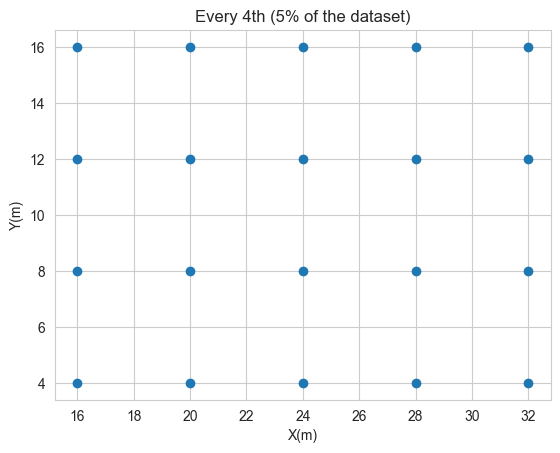

In [79]:
plot_RF(training_df_mean, "Every 4th (5% of the dataset)")

Best parameters: {'n_neighbors': 3}
Best score: -3.4376264137863983
Localization Error: 3.732049689309168


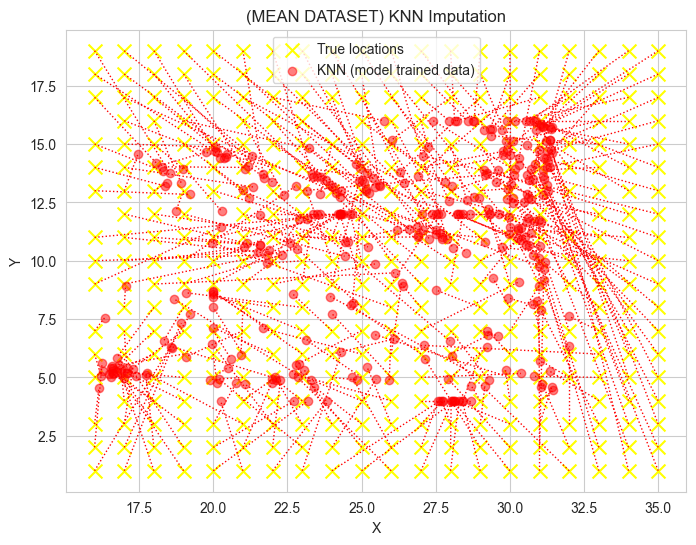

Best parameters: {'n_neighbors': 3}
Best score: -3.097002207674918
Localization Error: 3.68155554183252


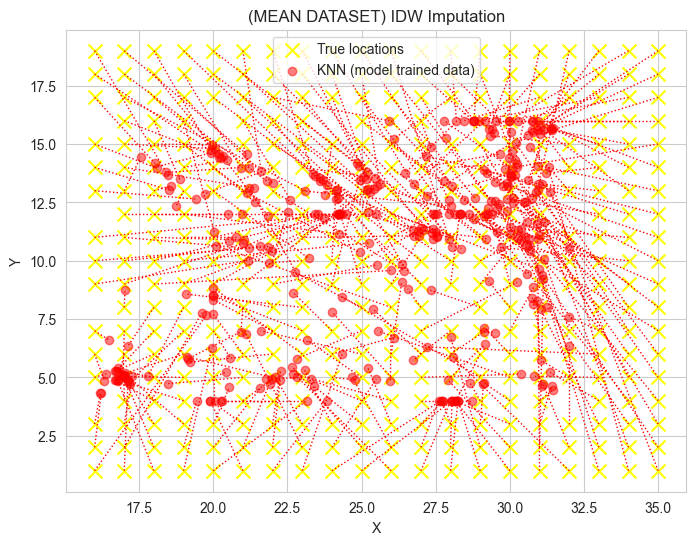

Best parameters: {'n_neighbors': 4}
Best score: -3.376074971666341
Localization Error: 4.286523913912439


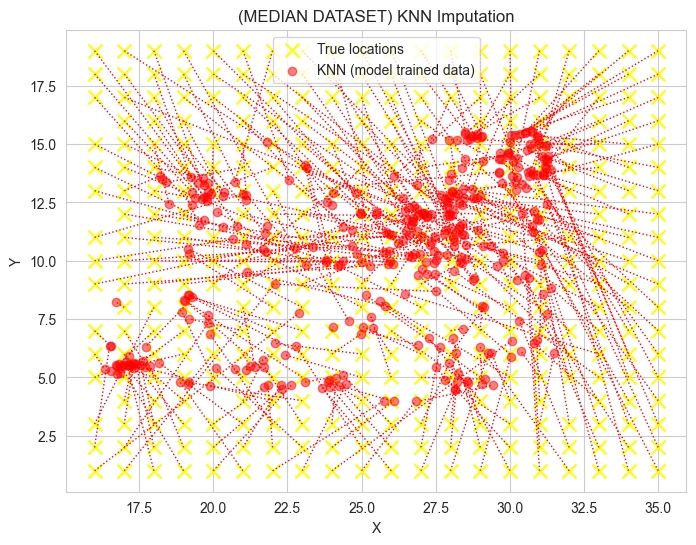

Best parameters: {'n_neighbors': 4}
Best score: -3.29888017971357
Localization Error: 4.178786781123294


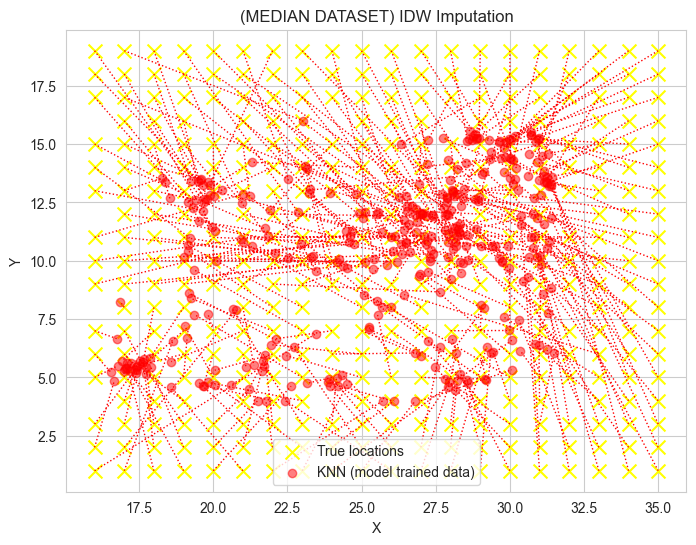

In [77]:
evaluate_knn(training_df_mean, test_df_mean, plot_label="(MEAN DATASET) KNN Imputation")
evaluate_knn(training_df_mean_imputed, test_df_mean_imputed, plot_label="(MEAN DATASET) IDW Imputation")
evaluate_knn(training_df_median, test_df_median, plot_label="(MEDIAN DATASET) KNN Imputation")
evaluate_knn(training_df_median_imputed, test_df_median_imputed, plot_label="(MEDIAN DATASET) IDW Imputation")

### Every 5th

In [84]:
training_df_mean, test_df_mean = subsample_every_n(df_mean_imputed_knn, 5, (0,0))
training_df_median, test_df_median = subsample_every_n(df_median_imputed_knn, 5, (0,0))
training_df_mean_imputed, test_df_mean_imputed = subsample_every_n(ap_mean_by_xy_imputed, 5, (0,0))
training_df_median_imputed, test_df_median_imputed = subsample_every_n(ap_median_by_xy_imputed, 5, (0,0))

print(f"Fraction (original mean): {fraction(training_df_mean, ap_mean_by_xy)}")
print(f"Fraction (original median): {fraction(training_df_median, ap_median_by_xy)}")
print(f"Fraction (imputed mean): {fraction(training_df_mean_imputed, ap_mean_by_xy_imputed)}")
print(f"Fraction (imputed median: {fraction(training_df_median_imputed, ap_median_by_xy_imputed)}")

Fraction (original mean): 3.1578947368421053
Fraction (original median): 3.1578947368421053
Fraction (imputed mean): 3.1578947368421053
Fraction (imputed median: 3.1578947368421053


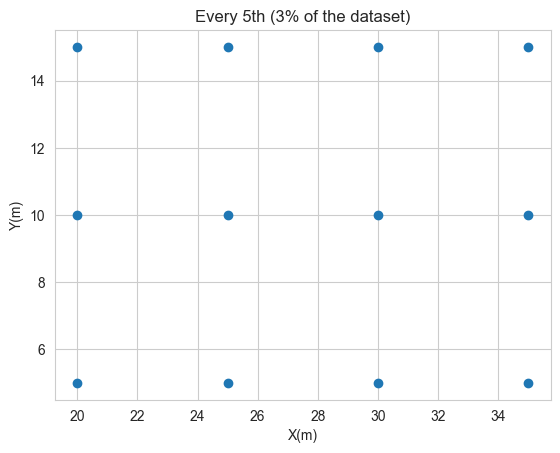

In [86]:
plot_RF(training_df_mean, "Every 5th (3% of the dataset)")

Best parameters: {'n_neighbors': 4}
Best score: -3.5571294542718563
Localization Error: 5.31341717649492


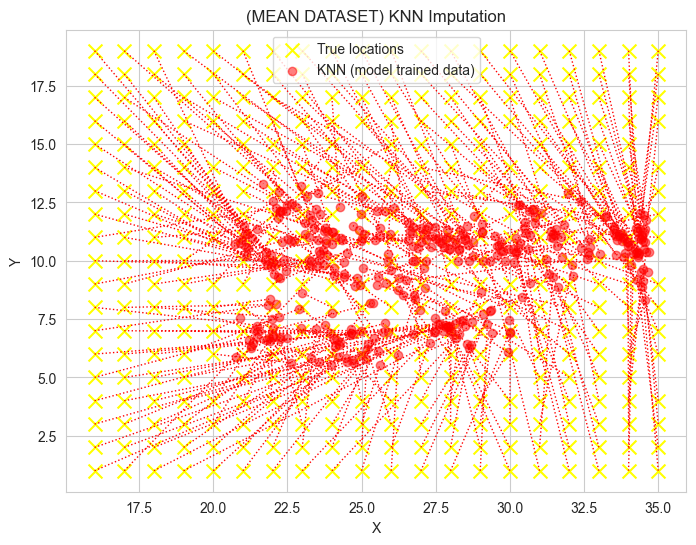

Best parameters: {'n_neighbors': 4}
Best score: -3.525331129057041
Localization Error: 5.1649398220142295


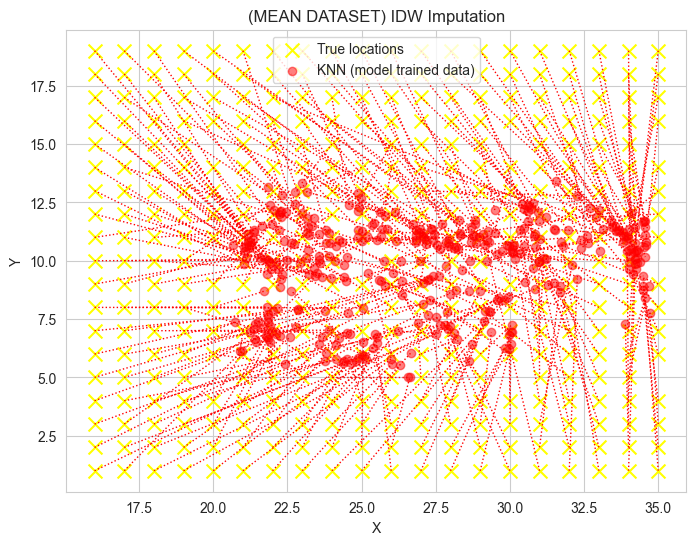

Best parameters: {'n_neighbors': 5}
Best score: -3.8682826174247014
Localization Error: 5.829348766901353


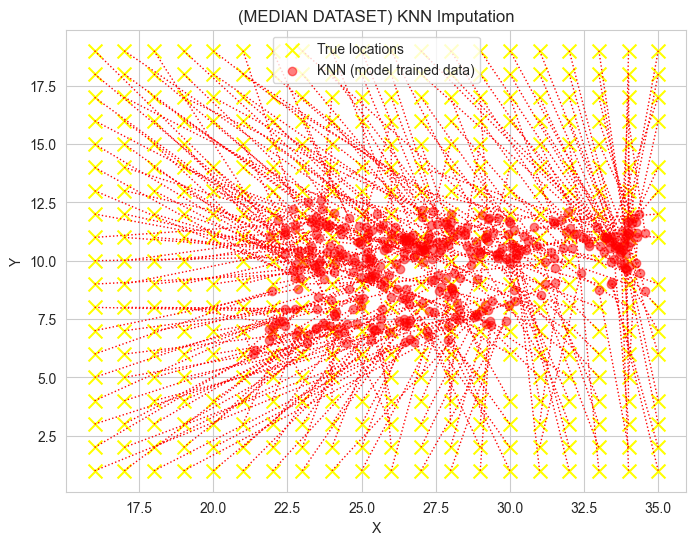

Best parameters: {'n_neighbors': 5}
Best score: -3.867801556498103
Localization Error: 5.702260947131104


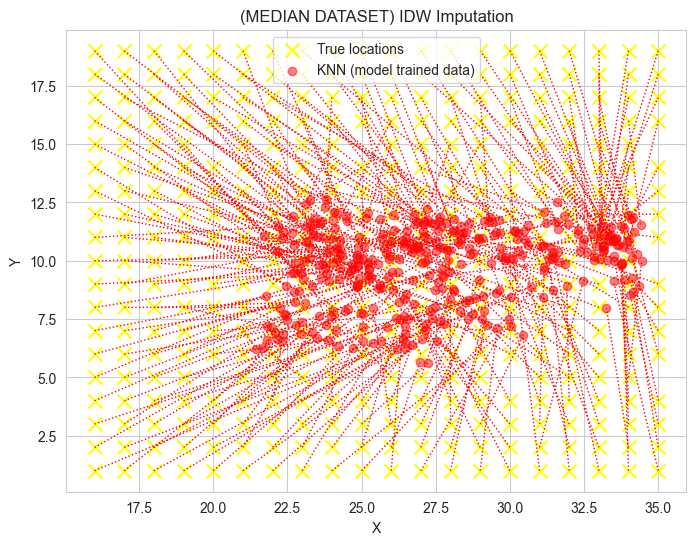

In [87]:
evaluate_knn(training_df_mean, test_df_mean, plot_label="(MEAN DATASET) KNN Imputation")
evaluate_knn(training_df_mean_imputed, test_df_mean_imputed, plot_label="(MEAN DATASET) IDW Imputation")
evaluate_knn(training_df_median, test_df_median, plot_label="(MEDIAN DATASET) KNN Imputation")
evaluate_knn(training_df_median_imputed, test_df_median_imputed, plot_label="(MEDIAN DATASET) IDW Imputation")